In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! pip install --upgrade --force-reinstall numpy
! pip install mediapipe
! pip install opencv-python
! pip uninstall -y numpy opencv-python mediapipe
! pip install numpy opencv-python mediapipe
! pip install mediapipe opencv-python tqdm

In [3]:
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126102 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [4]:
# matplotlib 캐시 강제 삭제
!rm -rf ~/.cache/matplotlib

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44544 (\N{HANGUL SYLLABLE GEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54256 (\N{HANGUL SYLLABLE PON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

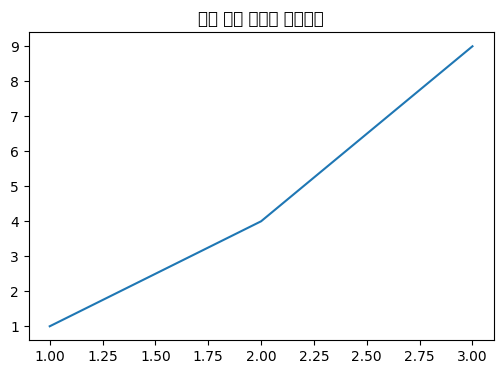

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 경로 직접 지정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# 전역 설정
plt.rcParams['font.family'] = fontprop.get_name()
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6,4))
plt.title('한글 폰트 제대로 적용됐다')
plt.plot([1, 2, 3], [1, 4, 9])
plt.show()

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [9]:
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split # train_test_split은 데이터가 로드된 후 사용
import pandas as pd
from collections import Counter

# 1. PoseTransformerDataset 클래스 정의 (디버깅 프린트문 포함)
class PoseTransformerDataset(Dataset):
    def __init__(self, data_dir):
        self.samples = []
        print(f"--- PoseTransformerDataset 초기화 시작 ---")
        print(f"데이터 로드 시도 경로 (절대 경로): {os.path.abspath(data_dir)}")

        if not os.path.exists(data_dir):
            print(f"오류: 데이터 디렉토리 '{data_dir}'를 찾을 수 없습니다. 경로를 확인해주세요.")
            print(f"--- PoseTransformerDataset 초기화 종료 (실패) ---")
            return

        if not os.listdir(data_dir):
            print(f"경고: 데이터 디렉토리 '{data_dir}'가 비어있습니다. 내부에 클래스별 서브 디렉토리가 있는지 확인해주세요.")
            print(f"--- PoseTransformerDataset 초기화 종료 (데이터 없음) ---")
            return

        print(f"'{data_dir}' 디렉토리 내용: {os.listdir(data_dir)}")
        for label_dir_name in os.listdir(data_dir): # data_dir의 각 항목 (클래스 디렉토리)
            full_label_dir_path = os.path.join(data_dir, label_dir_name)
            print(f"  확인 중인 항목: {full_label_dir_path}")

            if not os.path.isdir(full_label_dir_path):
                print(f"    '{label_dir_name}'는 디렉토리가 아니므로 건너뜁니다.")
                continue
            
            print(f"    '{label_dir_name}'는 디렉토리입니다. 내부 JSON 파일을 검색합니다...")
            json_file_found_in_subdir = False
            for file_name in os.listdir(full_label_dir_path): # 클래스 디렉토리 내부의 각 파일
                if file_name.endswith('.json'):
                    json_file_found_in_subdir = True
                    json_file_path = os.path.join(full_label_dir_path, file_name)
                    print(f"      JSON 파일 발견: {json_file_path}")
                    try:
                        with open(json_file_path, 'r', encoding='utf-8') as f: # encoding 명시
                            data = json.load(f)
                        
                        if "keypoints" not in data:
                            print(f"        경고: '{json_file_path}' 파일에 'keypoints' 키가 없습니다. 건너뜁니다.")
                            continue
                        if "label" not in data:
                            print(f"        경고: '{json_file_path}' 파일에 'label' 키가 없습니다. 건너뜁니다.")
                            continue
                            
                        # Mediapipe Pose의 경우 33개의 랜드마크, 각 랜드마크는 x, y, z, visibility 등을 가질 수 있음
                        # 여기서는 (33, 3) 형태로 x, y, z를 가정하고, 그 중 x, y만 사용 ([:, :2])
                        keypoints_data = data["keypoints"]
                        try:
                            keypoints = np.array(keypoints_data).reshape(33, 3)[:, :2]  # (33, 2)
                        except ValueError as e:
                            print(f"        오류: '{json_file_path}' 파일의 'keypoints' 데이터 형태 오류 ({np.array(keypoints_data).shape}): {e}. 건너뜁니다.")
                            continue
                            
                        label = int(data["label"])
                        self.samples.append((keypoints, label))
                        # print(f"        성공적으로 로드 및 추가. 현재 총 샘플 수: {len(self.samples)}")
                    except json.JSONDecodeError as e:
                        print(f"        오류: '{json_file_path}' 파일 JSON 디코딩 오류: {e}. 건너뜁니다.")
                    except Exception as e:
                        print(f"        오류: '{json_file_path}' 파일 처리 중 예외 발생: {e}. 건너뜁니다.")
            
            if not json_file_found_in_subdir:
                print(f"    경고: '{full_label_dir_path}' 디렉토리 내에 JSON 파일을 찾지 못했습니다.")
        
        print(f"--- PoseTransformerDataset 초기화 종료. 총 로드된 샘플 수: {len(self.samples)} ---")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        coords, label = self.samples[idx]
        # self.samples에는 numpy 배열과 int가 저장되어 있음
        # DataLoader에서 사용될 때 텐서로 변환
        return torch.tensor(coords, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# 2. SampleListDataset 클래스 정의
#    train_test_split으로 분리된 데이터(numpy array, int 리스트)를 받아 PyTorch Dataset으로 만듭니다.
class SampleListDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples # samples는 (좌표_numpy_배열, 라벨_int) 형태의 튜플 리스트

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        coords, label = self.samples[idx]
        # NumPy 배열과 int 라벨을 PyTorch 텐서로 변환
        return torch.tensor(coords, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# 3. 데이터 경로 지정 및 기본 경로 확인
data_path = "joint_point_dataset/new_정리된_관절좌표" # 사용자의 실제 데이터셋 경로로 수정하세요.

print(f"--- 스크립트 시작 ---")
print(f"현재 작업 디렉토리: {os.getcwd()}")
print(f"지정된 데이터 경로 (상대): {data_path}")
print(f"계산된 데이터 경로 (절대): {os.path.abspath(data_path)}")

if not os.path.exists(data_path):
    print(f"치명적 오류: 지정된 데이터 경로 '{os.path.abspath(data_path)}'가 존재하지 않습니다. 스크립트를 종료합니다.")
    exit() # 경로 없으면 실행 중단

if not os.listdir(data_path):
    print(f"치명적 오류: 데이터 경로 '{os.path.abspath(data_path)}'는 존재하지만 비어있습니다. 내부에 클래스별 서브 디렉토리가 있는지 확인하세요. 스크립트를 종료합니다.")
    exit() # 경로가 비어있으면 실행 중단

# 4. PoseTransformerDataset 인스턴스 생성
dataset = PoseTransformerDataset(data_path)

# 5. 데이터셋 로드 성공 여부 확인 및 데이터 분할/로더 생성
if not dataset.samples:
    print("오류: PoseTransformerDataset에서 샘플을 로드하지 못했습니다. 위의 로그를 확인하여 문제를 해결하세요.")
    print("데이터 경로, 디렉토리 구조, JSON 파일 형식 및 내용을 점검해주세요.")
else:
    print(f"\n--- 데이터 분할 및 DataLoader 생성 시작 ---")
    print(f"총 {len(dataset.samples)}개의 샘플이 성공적으로 로드되었습니다.")

    # 라벨 추출 (stratify 옵션 사용 위함)
    labels_for_stratify = [sample[1] for sample in dataset.samples]

    # train_test_split은 dataset.samples (튜플 리스트)를 사용합니다.
    # 각 튜플은 (numpy_array_keypoints, int_label) 형태입니다.
    try:
        trainval_data, test_data = train_test_split(dataset.samples,
                                                    test_size=0.2,
                                                    stratify=labels_for_stratify,
                                                    random_state=42) # 재현성을 위한 random_state

        trainval_labels_for_stratify = [sample[1] for sample in trainval_data]
        train_data, val_data = train_test_split(trainval_data,
                                                test_size=0.1, # trainval_data의 10% -> 전체 데이터의 8%
                                                stratify=trainval_labels_for_stratify,
                                                random_state=42)
    except ValueError as e:
        print(f"데이터 분할 중 오류 발생: {e}")
        print("클래스별 샘플 수가 너무 적을 경우 stratify 옵션에서 오류가 발생할 수 있습니다.")
        print("test_size 또는 클래스별 샘플 수를 확인하세요.")
        # 오류 발생 시 아래 코드 실행 안함
        train_data, val_data, test_data = None, None, None


    if train_data and val_data and test_data:
        print(f"데이터 분할 결과: Train {len(train_data)}, Validation {len(val_data)}, Test {len(test_data)}")

        # SampleListDataset을 사용하여 DataLoader 생성
        train_dataset_processed = SampleListDataset(train_data)
        val_dataset_processed = SampleListDataset(val_data)
        test_dataset_processed = SampleListDataset(test_data)

        train_loader = DataLoader(train_dataset_processed, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset_processed, batch_size=16, shuffle=False)
        test_loader = DataLoader(test_dataset_processed, batch_size=16, shuffle=False)

        print("Train, Validation, Test DataLoader가 성공적으로 생성되었습니다.")

        # 6. 라벨 분포 시각화 (데이터프레임으로 출력)
        print("\n--- 전체 데이터셋 라벨 분포 ---")
        original_label_counts = Counter([sample[1] for sample in dataset.samples])
        df_original_label = pd.DataFrame(sorted(original_label_counts.items()), columns=["Label", "Count"])
        print(df_original_label)

        print("\n--- 학습 데이터셋 라벨 분포 ---")
        train_label_counts = Counter([sample[1] for sample in train_data])
        df_train_label = pd.DataFrame(sorted(train_label_counts.items()), columns=["Label", "Count"])
        print(df_train_label)

        # 예시: train_loader의 첫번째 배치 데이터 확인
        # for batch_coords, batch_labels in train_loader:
        #     print("\n--- 첫번째 학습 배치 데이터 확인 ---")
        #     print(f"Batch Coords Shape: {batch_coords.shape}") # (batch_size, 33, 2)
        #     print(f"Batch Labels Shape: {batch_labels.shape}") # (batch_size)
        #     print(f"Batch Labels: {batch_labels}")
        #     break
    else:
        print("데이터 분할에 실패하여 DataLoader를 생성할 수 없습니다.")

print(f"--- 스크립트 종료 ---")

--- 스크립트 시작 ---
현재 작업 디렉토리: c:\Users\LG\taekwondo_forms\taekwon_form
지정된 데이터 경로 (상대): joint_point_dataset/new_정리된_관절좌표
계산된 데이터 경로 (절대): c:\Users\LG\taekwondo_forms\taekwon_form\joint_point_dataset\new_정리된_관절좌표
--- PoseTransformerDataset 초기화 시작 ---
데이터 로드 시도 경로 (절대 경로): c:\Users\LG\taekwondo_forms\taekwon_form\joint_point_dataset\new_정리된_관절좌표
'joint_point_dataset/new_정리된_관절좌표' 디렉토리 내용: ['class_0', 'class_1', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_2', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9']
  확인 중인 항목: joint_point_dataset/new_정리된_관절좌표\class_0
    'class_0'는 디렉토리입니다. 내부 JSON 파일을 검색합니다...
      JSON 파일 발견: joint_point_dataset/new_정리된_관절좌표\class_0\관절좌표A_0_KR_A_2D_0001.json
      JSON 파일 발견: joint_point_dataset/new_정리된_관절좌표\class_0\관절좌표A_0_KR_A_2D_0002.json
      JSON 파일 발견: joint_point_dataset/new_정리된_관절좌표\class_0\관절좌표A_0_KR_A_2D_0003.json
      JSON 파일 발견: joint_point_dataset/new_정리된_관절좌표\c

In [11]:
class PoseTransformer(nn.Module):
    def __init__(self, input_dim=66, num_classes=18):
        super().__init__()
        self.embedding = nn.Linear(input_dim, 256)
        encoder_layer = nn.TransformerEncoderLayer(d_model=256, nhead=8, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=4)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):  # x: (B, 33, 2)
        x = x.view(x.size(0), -1).unsqueeze(1)  # (B, 1, 66)
        x = self.embedding(x)                  # (B, 1, 256)
        x = self.encoder(x)                    # (B, 1, 256)
        x = x.mean(dim=1)                      # (B, 256)
        return self.fc(x)                      # (B, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoseTransformer().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

In [12]:
def train_model(model, train_loader, val_loader, patience=10, num_epochs=100):
    best_loss, best_acc = float('inf'), 0
    best_model, best_epoch = None, 0
    stop_count = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss, train_correct = 0, 0
        total = 0

        for x, y in train_loader:
            x, y = x.float().to(device), y.to(device)  # ← float32 변환
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            train_correct += (output.argmax(1) == y).sum().item()
            total += x.size(0)

        train_acc = train_correct / total
        train_loss /= total

        # Validation
        model.eval()
        val_loss, val_correct = 0, 0
        total_val = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.float().to(device), y.to(device)  # ← float32 변환
                output = model(x)
                loss = criterion(output, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (output.argmax(1) == y).sum().item()
                total_val += x.size(0)

        val_acc = val_correct / total_val
        val_loss /= total_val

        print(f"[{epoch+1:03}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            best_acc = val_acc
            best_epoch = epoch + 1
            best_model = model.state_dict()
            stop_count = 0
        else:
            stop_count += 1
            if stop_count >= patience:
                print("🛑 Early stopping!")
                break

    model.load_state_dict(best_model)
    print(f"\n✅ Best Epoch: {best_epoch}, Val Loss: {best_loss:.4f}, Val Acc: {best_acc:.4f}")
    return model

model = train_model(model, train_loader, val_loader)

[001] Train Loss: 1.5714 | Train Acc: 0.4740 | Val Loss: 0.9941 | Val Acc: 0.6700
[002] Train Loss: 0.8297 | Train Acc: 0.7139 | Val Loss: 0.6812 | Val Acc: 0.7544
[003] Train Loss: 0.5579 | Train Acc: 0.8049 | Val Loss: 0.4508 | Val Acc: 0.8387
[004] Train Loss: 0.4302 | Train Acc: 0.8468 | Val Loss: 0.3827 | Val Acc: 0.8634
[005] Train Loss: 0.3670 | Train Acc: 0.8687 | Val Loss: 0.3748 | Val Acc: 0.8616
[006] Train Loss: 0.3073 | Train Acc: 0.8928 | Val Loss: 0.2685 | Val Acc: 0.8937
[007] Train Loss: 0.2543 | Train Acc: 0.9103 | Val Loss: 0.2146 | Val Acc: 0.9120
[008] Train Loss: 0.2590 | Train Acc: 0.9085 | Val Loss: 0.1727 | Val Acc: 0.9331
[009] Train Loss: 0.2290 | Train Acc: 0.9198 | Val Loss: 0.2739 | Val Acc: 0.9001
[010] Train Loss: 0.2127 | Train Acc: 0.9247 | Val Loss: 0.1780 | Val Acc: 0.9377
[011] Train Loss: 0.2007 | Train Acc: 0.9330 | Val Loss: 0.1941 | Val Acc: 0.9267
[012] Train Loss: 0.1875 | Train Acc: 0.9346 | Val Loss: 0.1461 | Val Acc: 0.9413
[013] Train Loss

🎯 Test Accuracy: 94.65%


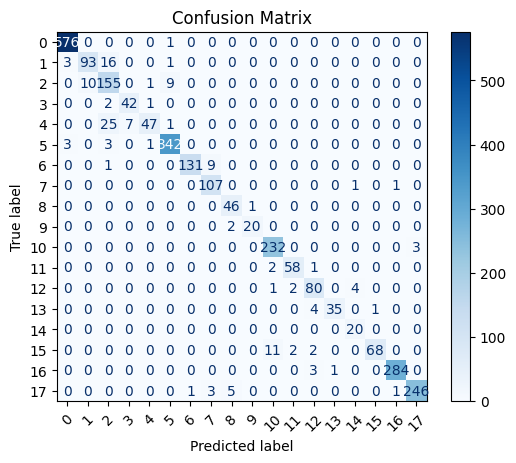

In [13]:
# 테스트 예측
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.float().to(device)  # ← dtype 문제 해결!
        output = model(x)
        preds = output.argmax(1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y.numpy())

acc = accuracy_score(y_true, y_pred)
print(f"🎯 Test Accuracy: {acc*100:.2f}%")

# 혼동행렬
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# 클래스 파일 정리

In [ ]:
# import os
# import shutil

# def organize_keypoints_by_class(source_dir, target_dir):
#     """
#     source_dir: 기존 폴더 (new_관절좌표)
#     target_dir: 정리할 폴더 (예: new_정리된_관절좌표)
#     """

#     if not os.path.exists(target_dir):
#         os.makedirs(target_dir)

#     # 0~17 클래스 폴더 미리 생성
#     for i in range(18):
#         os.makedirs(os.path.join(target_dir, f'class_{i}'), exist_ok=True)

#     # 관절좌표A~F 폴더를 순회
#     for person_folder in os.listdir(source_dir):
#         person_path = os.path.join(source_dir, person_folder)
#         if not os.path.isdir(person_path):
#             continue

#         for filename in os.listdir(person_path):
#             if filename.endswith('.json'):
#                 # 파일명에서 동작 번호 추출
#                 action_class = int(filename.split('_')[0])
#                 src_path = os.path.join(person_path, filename)
#                 dst_path = os.path.join(target_dir, f'class_{action_class}', f"{person_folder}_{filename}")

#                 # 복사
#                 shutil.copy(src_path, dst_path)

#     print("✅ 클래스별 정리 완료!")

# source_dir = "/content/drive/MyDrive/수업관련/4-1/데이터수집과처리/new_관절좌표"
# target_dir = "/content/drive/MyDrive/수업관련/4-1/데이터수집과처리/new_정리된_관절좌표"

# organize_keypoints_by_class(source_dir, target_dir)

# 새로운 이미지에서 관절좌표 추출

In [14]:
import cv2
import mediapipe as mp
import numpy as np

def extract_keypoints_from_image(image_path):
    mp_pose = mp.solutions.pose
    pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Image not found: {image_path}")

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    result = pose.process(image_rgb)

    if not result.pose_landmarks:
        raise ValueError("No pose landmarks detected.")

    landmarks = result.pose_landmarks.landmark

    # (33개 관절) x (x, y) 2D 좌표 추출
    keypoints = np.array([[lm.x, lm.y] for lm in landmarks])  # (33, 2)

    return keypoints  # numpy array로 반환

# 모델 로드 및 새로운 이미지 클래스 분류하기

In [15]:
import torch

def predict_pose_class(model, keypoints, device):
    model.eval()
    keypoints = torch.tensor(keypoints, dtype=torch.float32).view(1, 33, 2)
    keypoints = keypoints.to(device)

    with torch.no_grad():
        output = model(keypoints)
        pred_class = output.argmax(dim=1).item()

    return pred_class

# 유사도 측정

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

def calculate_similarity(user_keypoints, reference_keypoints_list):
    user_vec = user_keypoints.flatten().reshape(1, -1)  # (1, 66)

    similarities = []
    for ref in reference_keypoints_list:
        ref_vec = ref.flatten().reshape(1, -1)
        sim = cosine_similarity(user_vec, ref_vec)[0][0]
        similarities.append(sim)

    best_idx = np.argmax(similarities)
    best_similarity = similarities[best_idx]

    return best_idx, best_similarity


# 분류된 클래스 관절좌표 불러오기

In [17]:
import os
import json

def load_reference_keypoints(class_folder_path):
    """
    class_folder_path: /content/drive/.../new_정리된_관절좌표/class_N
    """
    keypoints_list = []
    filenames = []

    for file in os.listdir(class_folder_path):
        if file.endswith('.json'):
            with open(os.path.join(class_folder_path, file)) as f:
                data = json.load(f)
                keypoints = np.array(data["keypoints"]).reshape((33, 3))[:, :2]  # (33, 2)
                keypoints_list.append(keypoints)
                filenames.append(file)

    return keypoints_list, filenames


# 결과 시각화 확인

In [18]:
def visualize_user_and_reference(user_image_path, user_keypoints, reference_keypoints, connections):
    """
    user_image_path: 배경 이미지 경로
    user_keypoints: (33, 2) 사용자 관절좌표
    reference_keypoints: (33, 2) 유단자 관절좌표
    connections: 관절 연결 리스트
    """

    image = cv2.imread(user_image_path)
    if image is None:
        raise ValueError(f"Image not found: {user_image_path}")

    h, w, _ = image.shape

    # 사용자, 유단자 모두 스케일 맞추기
    user_keypoints = user_keypoints.copy()
    user_keypoints[:, 0] *= w
    user_keypoints[:, 1] *= h
    user_keypoints = user_keypoints.astype(int)

    reference_keypoints = reference_keypoints.copy()
    reference_keypoints[:, 0] *= w
    reference_keypoints[:, 1] *= h
    reference_keypoints = reference_keypoints.astype(int)

    # ------------------
    # 1. 사용자 관절 그리기 (빨간색 BGR: (0, 0, 255))
    for (x, y) in user_keypoints:
        cv2.circle(image, (x, y), 5, (0, 0, 255), -1)  # 빨간 점

    for joint1, joint2 in connections:
        x1, y1 = user_keypoints[joint1]
        x2, y2 = user_keypoints[joint2]
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)  # 빨간 선

    # ------------------
    # 2. 유단자 관절 그리기 (초록색 BGR: (0, 255, 0))
    for (x, y) in reference_keypoints:
        cv2.circle(image, (x, y), 5, (0, 255, 0), -1)  # 초록 점

    for joint1, joint2 in connections:
        x1, y1 = reference_keypoints[joint1]
        x2, y2 = reference_keypoints[joint2]
        cv2.line(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # 초록 선

    return image

# 준비한 POSE_CONNECTIONS (Mediapipe 연결) 다시 정리
POSE_CONNECTIONS = [
    (11, 13), (13, 15),
    (12, 14), (14, 16),
    (11, 12),
    (11, 23), (12, 24),
    (23, 24),
    (23, 25), (25, 27),
    (24, 26), (26, 28),
    (27, 29), (28, 30),
    (29, 31), (30, 32)
]

# ✅ Mediapipe Pose 관절 번호(landmark index) 정리

# 번호	신체 부위 이름	의미/설명

In [ ]:
# 0	Nose	코 (정면 기준)
# 1	Left Eye Inner	왼쪽 눈 안쪽
# 2	Left Eye	왼쪽 눈
# 3	Left Eye Outer	왼쪽 눈 바깥쪽
# 4	Right Eye Inner	오른쪽 눈 안쪽
# 5	Right Eye	오른쪽 눈
# 6	Right Eye Outer	오른쪽 눈 바깥쪽
# 7	Left Ear	왼쪽 귀
# 8	Right Ear	오른쪽 귀
# 9	Mouth Left	입 왼쪽 끝
# 10	Mouth Right	입 오른쪽 끝
# 11	Left Shoulder	왼쪽 어깨
# 12	Right Shoulder	오른쪽 어깨
# 13	Left Elbow	왼쪽 팔꿈치
# 14	Right Elbow	오른쪽 팔꿈치
# 15	Left Wrist	왼쪽 손목
# 16	Right Wrist	오른쪽 손목
# 17	Left Pinky	왼쪽 새끼손가락 끝
# 18	Right Pinky	오른쪽 새끼손가락 끝
# 19	Left Index	왼쪽 집게손가락 끝
# 20	Right Index	오른쪽 집게손가락 끝
# 21	Left Thumb	왼쪽 엄지손가락 끝
# 22	Right Thumb	오른쪽 엄지손가락 끝
# 23	Left Hip	왼쪽 골반 (허리 좌측)
# 24	Right Hip	오른쪽 골반 (허리 우측)
# 25	Left Knee	왼쪽 무릎
# 26	Right Knee	오른쪽 무릎
# 27	Left Ankle	왼쪽 발목
# 28	Right Ankle	오른쪽 발목
# 29	Left Heel	왼쪽 뒤꿈치
# 30	Right Heel	오른쪽 뒤꿈치
# 31	Left Foot Index	왼쪽 발가락 (엄지발가락 근처)
# 32	Right Foot Index	오른쪽 발가락 (엄지발가락 근처)

In [22]:
# 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 사용자 이미지 경로 리스트
user_image_paths = [
    "blackbelt_H/04/KR_H_2D_0703.jpg",
    "tblackbelt_H/16/KR_H_2D_2531.jpg",
    "test/KR_H_2D_2856.jpg",
    "test/KR_H_2D_3107.jpg",
    "test/KR_H_2D_3591.jpg"
]

reference_base_path = "taekwon_form/joint_point_dataset/new_정리된_관절좌표"  # 유단자 관절 좌표가 저장된 기본 경로

# 5개 이미지 모두 순차 처리
for idx, user_image_path in enumerate(user_image_paths):
    print(f"\n========== [ {idx+1} 번째 이미지 처리 중 ] ==========")
    print(f"파일명: {os.path.basename(user_image_path)}")

    # 1. 사용자 관절 추출
    user_keypoints = extract_keypoints_from_image(user_image_path)

    # 2. 분류
    predicted_class = predict_pose_class(model, user_keypoints, device)
    print(f"예측된 동작 클래스 번호: {predicted_class}")

    # 3. 해당 클래스 유단자 좌표 불러오기
    class_folder = os.path.join(reference_base_path, f"class_{predicted_class}")
    reference_keypoints_list, filenames = load_reference_keypoints(class_folder)

    # 4. 유사도 계산
    best_idx, best_similarity = calculate_similarity(user_keypoints, reference_keypoints_list)

    # 5. 결과 출력
    print(f"✅ 예측된 동작 클래스: {predicted_class}")
    print(f"✅ 가장 비슷한 유단자 샘플 파일명: {filenames[best_idx]}")
    print(f"✅ 유사도 점수: {best_similarity * 100:.2f}%")

    # 6. 시각화 출력
    comparison_image = visualize_user_and_reference(
        user_image_path,
        user_keypoints,
        reference_keypoints_list[best_idx],
        POSE_CONNECTIONS
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(comparison_image, cv2.COLOR_BGR2RGB))
    plt.title(f"예측 클래스: {predicted_class}번\n유사도: {best_similarity*100:.2f}점", fontsize=16)
    plt.axis('off')
    plt.show()


========== [ 1 번째 이미지 처리 중 ] ==========
파일명: KR_H_2D_0703.jpg


ValueError: No pose landmarks detected.

In [23]:
# training.py 에서
# — 학습 완료 후 반환된 best model 이 model 변수에 담겨 있다고 가정
torch.save(model.state_dict(), 'pose_transformer.pth')
print("✅ Saved pose transformer weights to pose_transformer.pth")


✅ Saved pose transformer weights to pose_transformer.pth
